# Decision Tree for Medical Diagnosis

## Attribution
Please supply all citations that you used to complete this assignment. They should be in APA format.


1.   Reference Lab
2.   UCI Machine Learning Repository for data
3.   ChatGPT to fix errors

## Acknowledgement

 <cite>
Mallya, V. (2024, September 3). Linear Regression in Python. Sustainability Methods. https://sustainabilitymethods.org/index.php/Linear_Regression_in_Python

Grobler, J. (n.d.). Linear regression example. Scikit-learn. Retrieved January 21, 2025, from https://scikit-learn.org/1.5/auto_examples/linear_model/plot_ols.html

 <cite>



## Data

Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993). Breast Cancer Wisconsin (Diagnostic) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B.


## Two Parts to the Assignment

### Create an EIG Calculator

In this Section, you will create your own Expected Information Gain Calculator. Once you are done. Tell me the following:
1. What are the EIG values for each decision tree?

H(S) = - (4/9)log₂(4/9) - (5/9)log₂(5/9) ≈ 0.991

EIG(Sender in Contact) = 0.991 - [(4/9)(0) + (5/9)(0.722)] = 0.590

EIG(Subject mentions “IRS”) = 0.991 - [(5/9)(0.971) + (4/9)(0.811)] = 0.091

EIG(Has Attachment) = 0.991 - [(4/9)(1.000) + (5/9)(0.971)] = 0.007


2. Which of the decision trees would you select and why?

I would choose the decision tree that splits on Sender in Contact because it has the highest Expected Information Gain. Using log₂, the value for Sender in Contact is approximately 0.5900, which is much larger than Subject mentions “IRS”, which is approximately 0.0911, and Has Attachment, which is approximately 0.0072. Since Expected Information Gain measures how much a split reduces entropy, the Sender in Contact split is the best choice because it reduces the uncertainty in the dataset the most.

**remember to use log base 2!**

Image is from our lecture notes.

![three decision trees](https://github.com/dudaspm/ClassImages/blob/main/decisiontree_before.png?raw=true)

![three decision trees](https://github.com/dudaspm/ClassImages/blob/main/ml_Class_decision_tree.png?raw=true)

### Analyize the Wisconsin Breast Cancer Wisconsin (Diagnostic) Data
Using the Breast Cancer Wisconsin (Diagnostic) [Dataset]. Complete the following tasks.

**Dataset # 17**

**Note:** Please use random seed 887
With this data you will do the following:
1. Create an 80/20 training/testing dataset
2. Max Depth

Create a decision tree with max depth = 1

Create a graphviz tree of the decision tree (the tree itself)

Create a confusion matrix plot

3. min_samples_split

Create a decision tree with min sampling split = 10

Create a graphviz tree of the decision tree (the tree itself)

Create a confusion matrix plot

4. min_samples_leaf

Create a decision tree with min sampling leaf = 10

Create a graphviz tree of the decision tree (the tree itself)

Create a confusion matrix plot

5. no hyper-parameters

Create a decision tree (no hyper-parameters)

Create a graphviz tree of the decision tree (the tree itself)

Create a confusion matrix plot

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [ ]:
from sklearn.model_selection import train_test_split
data = breast_cancer_wisconsin_diagnostic.data.original
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=887)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf_depth = DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=887)
clf_depth.fit(X_train, y_train)
y_pred_depth = clf_depth.predict(X_test)

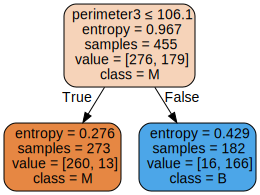

In [ ]:
feature_names = X.columns.tolist()
class_names = y.astype(str).unique().tolist()

from sklearn.tree import export_graphviz
from sklearn.metrics import ConfusionMatrixDisplay
import graphviz
import matplotlib.pyplot as plt

dot_data = export_graphviz(
    clf_depth,
    out_file=None,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

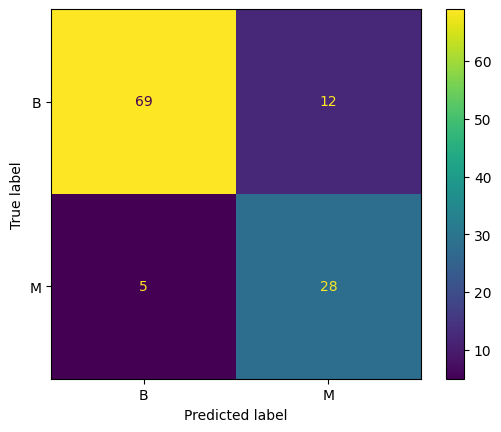

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_depth)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf_split = DecisionTreeClassifier(criterion='entropy', min_samples_split=10, random_state=887)
clf_split.fit(X_train, y_train)

y_pred_split = clf_split.predict(X_test)

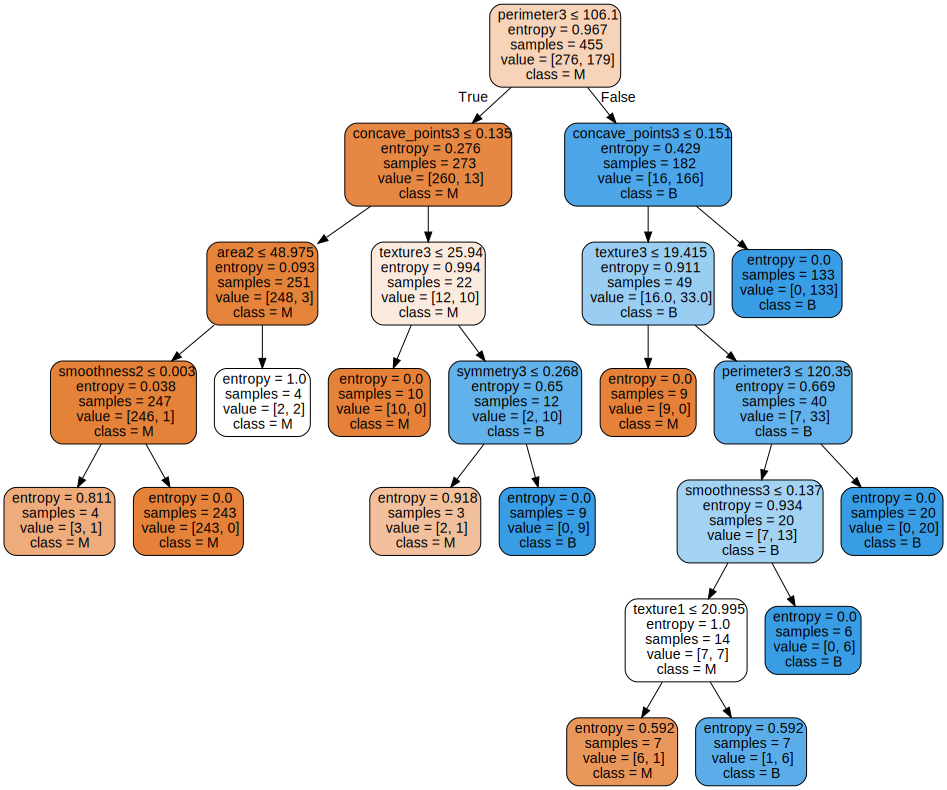

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

feature_names = X.columns.tolist()
class_names = y.astype(str).unique().tolist()

dot_data = export_graphviz(
    clf_split,
    out_file=None,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

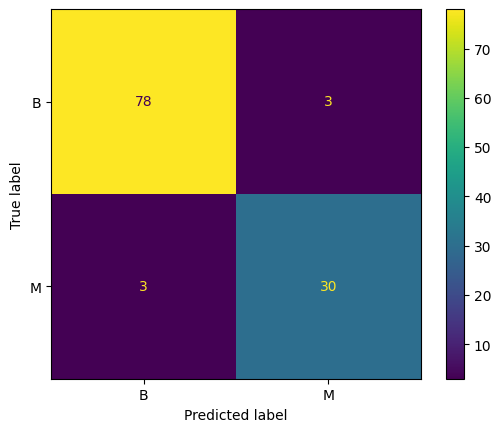

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_split)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf_leaf = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=10, random_state=887)
clf_leaf.fit(X_train, y_train)

y_pred_leaf = clf_leaf.predict(X_test)

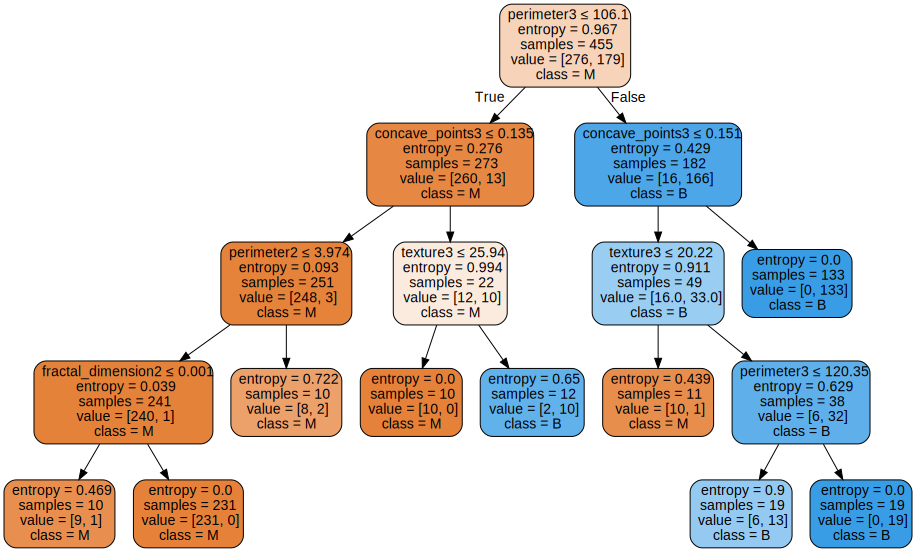

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

feature_names = X.columns.tolist()
class_names = y.astype(str).unique().tolist()

dot_data = export_graphviz(
    clf_leaf,
    out_file=None,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

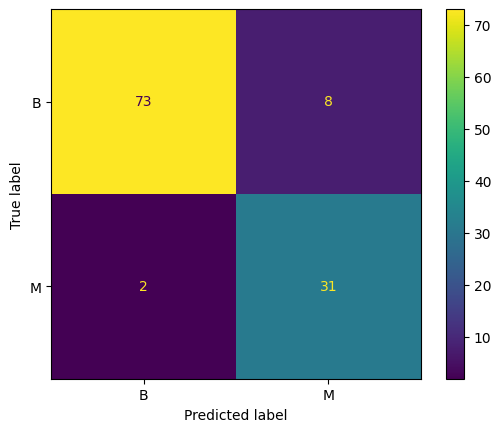

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_leaf)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf_default = DecisionTreeClassifier(criterion='entropy', random_state=887)
clf_default.fit(X_train, y_train)

y_pred_default = clf_default.predict(X_test)

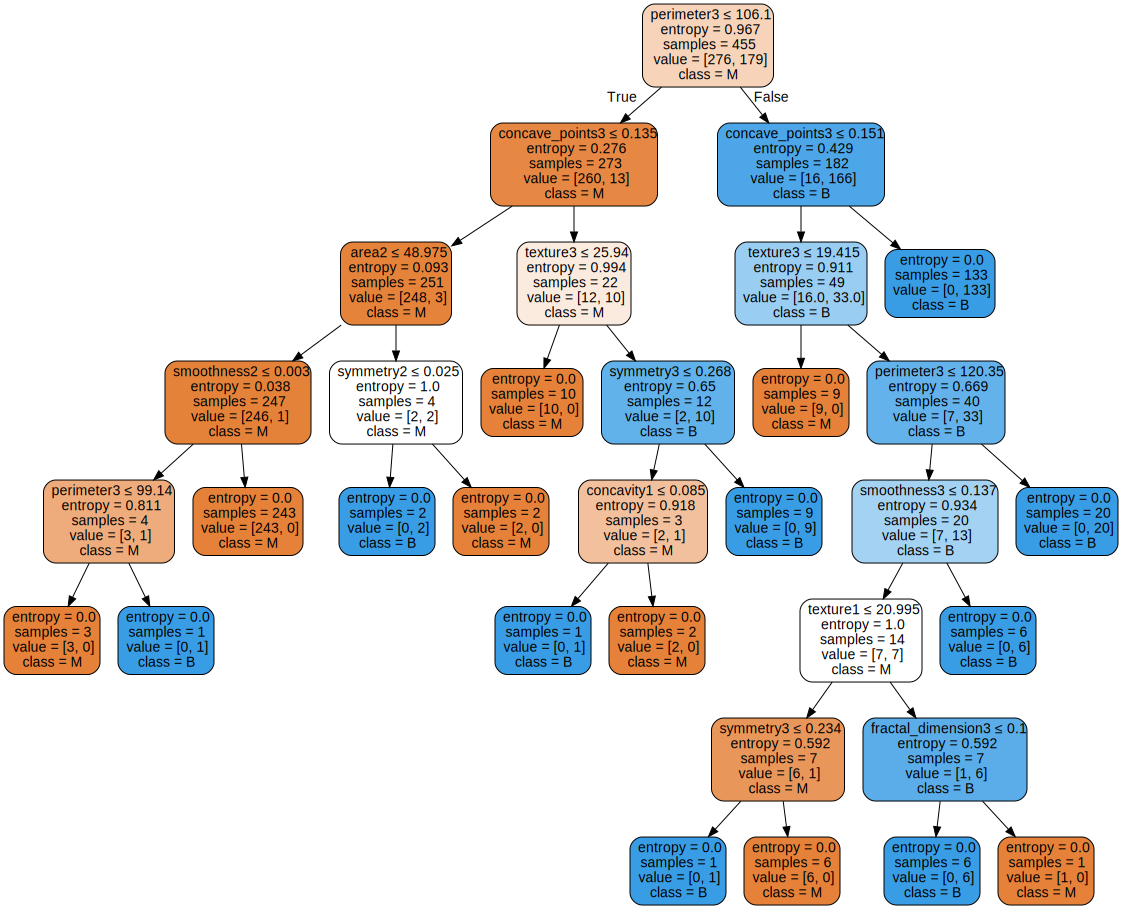

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

feature_names = X.columns.tolist()
class_names = y.astype(str).unique().tolist()

dot_data = export_graphviz(
    clf_default,
    out_file=None,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

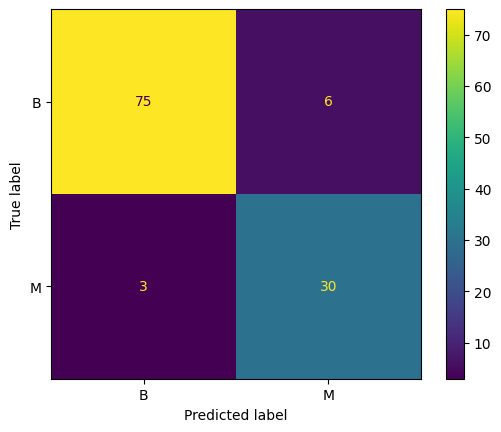

Max Depth Accuracy: 0.8508771929824561
Min Samples Split Accuracy: 0.9473684210526315
Min Samples Leaf Accuracy: 0.9122807017543859
Default Tree Accuracy: 0.9210526315789473


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_default)
plt.show()

from sklearn.metrics import accuracy_score

print("Max Depth Accuracy:", accuracy_score(y_test, y_pred_depth))
print("Min Samples Split Accuracy:", accuracy_score(y_test, y_pred_split))
print("Min Samples Leaf Accuracy:", accuracy_score(y_test, y_pred_leaf))
print("Default Tree Accuracy:", accuracy_score(y_test, y_pred_default))

After you finish these, answer the following questions?
1. Which is the best model for diagnosis?
1. Which is the worst model for diagnosis?
1. Why do you think these two models differed significantly?

The best model for diagnosis is the Min Samples Split (10) tree, as it the highest accuracy of 94.7%. It correctly classifies the most cases in the test set, so it is the strongest model for diagnosis.
It can capture more of the patterns in the breast cancer data.

The worst model for diagnosis is the max_depth = 1 tree, because it has an accuracy of only 85.1 percent. It is the most restricted model and can only make one split, so it usually underfits the data and misses important patterns needed for accurate diagnosis.

The Max Depth = 1 tree is very simple and cannot capture enough patterns in the features, leading to underfitting. The Min Samples Split = 10 tree can make multiple splits and capture more detailed relationships between features and diagnosis, improving predictive performance. The difference in flexibility directly affects accuracy, since more flexible models (up to a point) perform better, while overly constrained models miss information.